# 데이터셋 확인 (전처리)

🔍 원본 이미지 1개의 크기를 확인합니다...
[1/1] 파일: 20231122_094217_49748-95276.bmp, 크기(H x W): 1944 x 2592


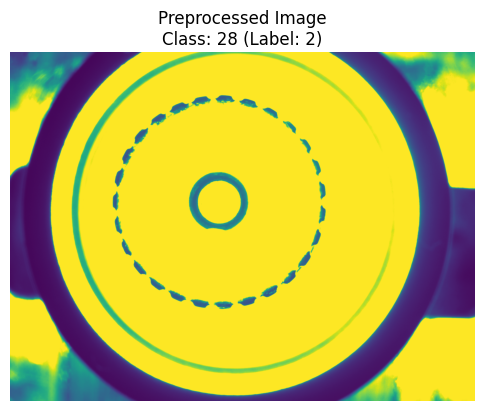

In [29]:
import os
from PIL import Image
import numpy as np

image_sizes = []
num_images_to_check = 1 # 전체 이미지 중 처음 100개만 확인 (모두 확인하려면 len(full_dataset) 사용)

print(f"🔍 원본 이미지 {num_images_to_check}개의 크기를 확인합니다...")

for i in range(min(num_images_to_check, len(full_dataset))):
    path, _ = full_dataset.samples[i]
    
    try:
        # PIL Image로 로드
        img = Image.open(path)
        
        # 원본 이미지의 크기 (Width, Height)
        width, height = img.size
        image_sizes.append((height, width))
        
        # 처음 몇 개만 예시로 출력
        if i < 5:
            print(f"[{i+1}/{num_images_to_check}] 파일: {os.path.basename(path)}, 크기(H x W): {height} x {width}")
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"Preprocessed Image\nClass: {first_label_name} (Label: {first_label_idx})")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"이미지 로드 오류 발생: {path}, 오류: {e}")

# 리스트를 NumPy 배열로 변환
image_sizes = np.array(image_sizes)

로드된 이미지 배치 shape: torch.Size([32, 3, 224, 224])
로드된 레이블 배치 shape: torch.Size([32])


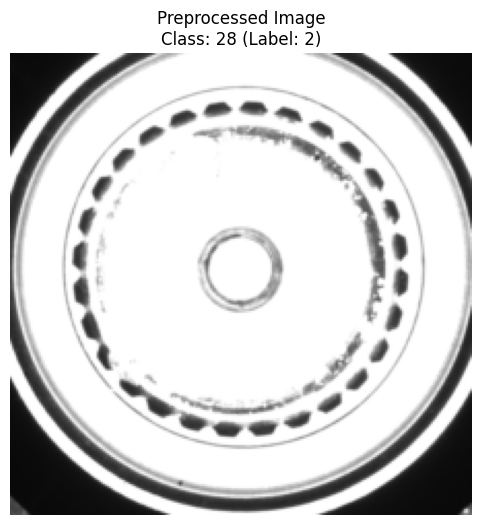

In [38]:
def denormalize_image(img_tensor, mean, std):
    # img_tensor: (C, H, W) 형태의 PyTorch Tensor
    img_tensor = img_tensor.clone() # 원본 텐서 변경 방지
    for t, m, s in zip(img_tensor, mean, std):
        t.mul_(s).add_(m) # t = t * s + m
    # PIL 이미지 형식 (H, W, C)로 변환하고 0-1 범위로 클리핑
    np_img = img_tensor.permute(1, 2, 0).numpy()
    np_img = np.clip(np_img, 0, 1)
    return np_img

try:
    images, labels = next(iter(dataloaders_final['train']))
    print(f"로드된 이미지 배치 shape: {images.shape}") # (Batch_Size, Channels, Height, Width)
    print(f"로드된 레이블 배치 shape: {labels.shape}") # (Batch_Size)

    # 첫 번째 이미지 선택
    first_image_tensor = images[0]
    first_label_idx = labels[0].item()
    first_label_name = class_names[first_label_idx]

    # 정규화된 이미지를 원본 스케일로 되돌리기 (시각화를 위해)
    denormalized_img = denormalize_image(first_image_tensor, IMAGENET_MEAN, IMAGENET_STD)

    # 이미지 시각화
    plt.figure(figsize=(6, 6))
    plt.imshow(denormalized_img)
    plt.title(f"Preprocessed Image\nClass: {first_label_name} (Label: {first_label_idx})")
    plt.axis('off')
    plt.show()

except StopIteration:
    print("DataLoader가 비어있습니다. 데이터를 불러올 수 없습니다.")
except Exception as e:
    print(f"이미지 시각화 중 오류 발생: {e}")


# 모델 학습

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from torchvision import models
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
from torch.utils.data import Dataset
import numpy as np
from tqdm import tqdm
import os
import glob
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import timm

# -----------------------------
# 1. 데이터 경로 및 설정
# -----------------------------
DATA_DIR = "/mnt/nas/seohan_image/seohan_data/origin"
BATCH_SIZE = 32
EPOCHS = 10
IMAGE_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 4

# -----------------------------
# 2. 클래스별 이미지 경로 수집
# -----------------------------
image_paths = []
labels = []

class_names = sorted(os.listdir(DATA_DIR))
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for img_path in glob.glob(os.path.join(cls_path, "*.bmp")):
        image_paths.append(img_path)
        labels.append(class_to_idx[cls])

print(f"총 이미지 개수: {len(image_paths)}")
print(f"클래스 목록: {class_names}")

# -----------------------------
# 3. Stratified Split
# -----------------------------
train_paths, val_paths, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}")

# -----------------------------
# 4. Custom Dataset
# -----------------------------
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        # Albumentations는 numpy array 사용
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']

        return image, label

# -----------------------------
# 5. Albumentations 변환 정의
# -----------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = A.Compose([
    A.CenterCrop(height=min(1944, 2592), width=min(1944, 2592)),
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5
    ),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.CenterCrop(height=min(1944, 2592), width=min(1944, 2592)),
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# -----------------------------
# 6. Dataset / DataLoader
# -----------------------------
train_dataset = CustomImageDataset(train_paths, y_train, transform=train_transforms)
val_dataset = CustomImageDataset(val_paths, y_val, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# -----------------------------
# 7. 클래스별 가중치 계산
# -----------------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"✅ Class Weights: {class_weights}")

# -----------------------------
# 8. 모델 로딩
# -----------------------------
def get_model(model_name, num_classes):
    if model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "mobilenetv2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "mobilenetv3":
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    elif model_name == "mobilevit_s":
        model = timm.create_model('mobilevit_s', pretrained=True, num_classes=num_classes)
    elif model_name == "efficientnet_b0":
        model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif model_name == "mobilenetv2_lite1":
        model = MobileNetV2_Lite(num_classes=num_classes, reduce_factor=0.5).to(DEVICE)
    elif model_name == "mobilenetv2_lite2":
        model = mobilenet_v2_light(num_classes=num_classes).to(DEVICE)
    elif model_name == "mobilenetv2_lite3":
        model = MobileNetV2_Custom(num_classes=num_classes).to(DEVICE)
    elif model_name == "mobilenetv2_width_mult":
        model = mobilenetv2_width_mult(num_classes=num_classes).to(DEVICE)
    elif model_name == "MobileNetV2_DepthLite":
        model = MobileNetV2_DepthLite(num_classes=num_classes).to(DEVICE)
    elif model_name == "MobileNetV2_Compact":
        model = MobileNetV2_Compact(num_classes=num_classes).to(DEVICE)
    else:
        raise ValueError(f"지원하지 않는 모델: {model_name}")

    return model.to(DEVICE)

# -----------------------------
# 9. 학습 및 검증 루프
# -----------------------------
def train_and_validate(model_name):
    model = get_model(model_name, num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    best_val_acc = 0.0
    os.makedirs("model", exist_ok=True)

    for epoch in range(EPOCHS):
        print(f"\nEpoch [{epoch+1}/{EPOCHS}] - {model_name}")

        # --- Training ---
        model.train()
        train_loss, train_correct = 0, 0
        for images, labels in tqdm(train_loader, desc="Train"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        # --- Validation ---
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Val"):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

        # --- Save best model ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"mobilenet/{model_name}_best.pth")
            print(f"✅ Best model saved ({val_acc:.4f})")



/home/dlit/miniconda3/envs/kdh/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


총 이미지 개수: 114213
클래스 목록: ['27_30', '27_45', '28', '31']
Train: 91370, Val: 22843


/home/dlit/miniconda3/envs/kdh/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


✅ Class Weights: tensor([0.8541, 2.1541, 0.4686, 4.3320], device='cuda:0')


In [ ]:
# -----------------------------
# 7. 실행 예시
# -----------------------------
for model_name in ["densenet121", "mobilenetv2", "mobilenetv3", "resnet50", "vgg16", "mobilevit_s", "efficientnet_b0"]:
    train_and_validate(model_name)

In [17]:
train_and_validate("mobilevit_s")


Epoch [1/10] - mobilevit_s


Val: 100%|██████████| 714/714 [17:44<00:00,  1.49s/it]


Train Loss: 0.0913, Acc: 0.9770 | Val Loss: 0.0050, Acc: 0.9989
✅ Best model saved (0.9989)

Epoch [2/10] - mobilevit_s


Val: 100%|██████████| 714/714 [15:22<00:00,  1.29s/it]


Train Loss: 0.0141, Acc: 0.9964 | Val Loss: 0.0059, Acc: 0.9987

Epoch [3/10] - mobilevit_s


Val: 100%|██████████| 714/714 [16:40<00:00,  1.40s/it]


Train Loss: 0.0098, Acc: 0.9975 | Val Loss: 0.0040, Acc: 0.9988

Epoch [4/10] - mobilevit_s


Train:  18%|█▊        | 501/2856 [07:33<44:50,  1.14s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [19]:
train_and_validate("efficientnet_b0")


Epoch [1/10] - efficientnet_b0


Val: 100%|██████████| 714/714 [14:46<00:00,  1.24s/it]


Train Loss: 0.0866, Acc: 0.9717 | Val Loss: 0.0097, Acc: 0.9972
✅ Best model saved (0.9972)

Epoch [2/10] - efficientnet_b0


Val: 100%|██████████| 714/714 [15:10<00:00,  1.27s/it]


Train Loss: 0.0193, Acc: 0.9941 | Val Loss: 0.0086, Acc: 0.9975
✅ Best model saved (0.9975)

Epoch [3/10] - efficientnet_b0


...

Train Loss: 0.0057, Acc: 0.9985 | Val Loss: 0.0023, Acc: 0.9993

Epoch [9/10] - efficientnet_b0


Val: 100%|██████████| 714/714 [12:24<00:00,  1.04s/it]


Train Loss: 0.0047, Acc: 0.9985 | Val Loss: 0.0017, Acc: 0.9995

Epoch [10/10] - efficientnet_b0


Val: 100%|██████████| 714/714 [13:55<00:00,  1.17s/it]

Train Loss: 0.0048, Acc: 0.9986 | Val Loss: 0.0026, Acc: 0.9992


### 경량화

In [4]:
import os
import glob
import torch
import torch.nn as nn
from torchvision import models
from tqdm import tqdm
import timm


# (1) Width Multiplier 축소
def mobilenetv2_width_mult(num_classes=4, width_mult=0.5):
    model = models.mobilenet_v2(weights=None, width_mult=width_mult)
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    return model


# (2) Depth 축소 (일부 블록 제거)
class MobileNetV2_DepthLite(nn.Module):
    def __init__(self, num_classes=4, remove_last_blocks=3):
        super().__init__()
        base_model = models.mobilenet_v2(weights=None)
        self.features = nn.Sequential(*list(base_model.features.children())[:-remove_last_blocks])

        dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            out_c = self.features(dummy).shape[1]

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(out_c, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# (3) Compact (채널 + 깊이 축소)
class MobileNetV2_Compact(nn.Module):
    def __init__(self, num_classes=4, width_mult=0.5, remove_last_blocks=3):
        super().__init__()
        base_model = models.mobilenet_v2(weights=None, width_mult=width_mult)
        self.features = nn.Sequential(*list(base_model.features.children())[:-remove_last_blocks])

        dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            out_c = self.features(dummy).shape[1]

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(out_c, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# -------------------------------------------------
# 모델 이름으로 생성하는 함수
# -------------------------------------------------
def create_model_from_name(model_name, num_classes):
    model_name_lower = model_name.lower()
    if "mobilenetv2_width_mult" in model_name_lower:
        return mobilenetv2_width_mult(num_classes=num_classes, reduce_factor=0.5)
    elif "MobileNetV2_DepthLite" in model_name_lower:
        return MobileNetV2_DepthLite(num_classes=num_classes)
    elif "MobileNetV2_Compact" in model_name_lower:
        return MobileNetV2_Compact(num_classes=num_classes, width_mult=0.5)
    else:
        raise ValueError(f"지원하지 않는 모델 유형입니다: {model_name}")


# -------------------------------------------------
# 평가 함수
# -------------------------------------------------
def evaluate_model(model, data_loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


In [5]:
for model_name in ["mobilenetv2_width_mult", "MobileNetV2_DepthLite", "MobileNetV2_Compact"]:
    train_and_validate(model_name)


Epoch [1/10] - mobilenetv2_width_mult


Val: 100%|██████████| 714/714 [16:19<00:00,  1.37s/it]


Train Loss: 0.7459, Acc: 0.6332 | Val Loss: 0.3533, Acc: 0.8336
✅ Best model saved (0.8336)

Epoch [2/10] - mobilenetv2_width_mult


Val: 100%|██████████| 714/714 [16:27<00:00,  1.38s/it]


Train Loss: 0.3661, Acc: 0.8431 | Val Loss: 0.1843, Acc: 0.9294
✅ Best model saved (0.9294)

Epoch [3/10] - mobilenetv2_width_mult


...

Val: 100%|██████████| 714/714 [16:20<00:00,  1.37s/it]


Train Loss: 0.0234, Acc: 0.9931 | Val Loss: 0.0090, Acc: 0.9977
✅ Best model saved (0.9977)

Epoch [10/10] - MobileNetV2_DepthLite


Val: 100%|██████████| 714/714 [16:21<00:00,  1.38s/it]


Train Loss: 0.0189, Acc: 0.9942 | Val Loss: 0.0090, Acc: 0.9968

Epoch [1/10] - MobileNetV2_Compact


Train:  77%|███████▋  | 2191/2856 [37:14<15:40,  1.41s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:

# --- 공통 설정 ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR = 'mobilenet'   # 모델이 저장된 폴더
NUM_CLASSES = 4               # 클래스 개수 (수정 필요)
test_loader = test_loader     # 이미 생성된 test_loader 사용

# --- 평가 실행 ---
model_files = glob.glob(os.path.join(MODEL_DIR, "*.pth"))

if not model_files:
    print(f"❌ '{MODEL_DIR}' 폴더에서 모델 파일을 찾을 수 없습니다.")
else:
    print(f"✅ {len(model_files)}개의 모델 파일을 찾았습니다.")
    model_performance = {}

    for model_path in model_files:
        model_name = os.path.basename(model_path)
        print(f"\n--- 모델 '{model_name}' 로드 및 평가 중 ---")

        try:
            # 모델 구조 복원
            model = create_model_from_name(model_name, NUM_CLASSES)
            state_dict = torch.load(model_path, map_location=DEVICE)
            model.load_state_dict(state_dict)
            model = model.to(DEVICE)

            # 파라미터 수 및 크기 계산
            total_params = sum(p.numel() for p in model.parameters())
            params_M = total_params / 1_000_000
            model_size_MB = os.path.getsize(model_path) / (1024 * 1024)

            # 모델 평가
            loss, accuracy = evaluate_model(model, test_loader, DEVICE)

            model_performance[model_name] = {
                'params_M': params_M,
                'model_size_MB': model_size_MB,
                'loss': loss,
                'accuracy': accuracy
            }

            print(f"✅ 평가 완료: {model_name}")
            print(f"   - 파라미터: {params_M:.2f}M, 모델 크기: {model_size_MB:.2f}MB")
            print(f"   - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

        except Exception as e:
            print(f"❌ 모델 '{model_name}' 로드/평가 실패: {e}")

    # --- 결과 요약 ---
    print("\n" + "="*90)
    print("📋 전체 모델 성능 요약 (정확도 순)")
    print("="*90)

    if model_performance:
        sorted_perf = sorted(model_performance.items(), key=lambda x: x[1]['accuracy'], reverse=True)
        print(f"{'모델 이름':<30} | {'파라미터 (M)':>12} | {'크기 (MB)':>12} | {'Loss':>8} | {'Acc':>8}")
        print("-"*90)
        for name, metrics in sorted_perf:
            print(f"{name:<30} | {metrics['params_M']:>12.2f} | {metrics['model_size_MB']:>12.2f} | {metrics['loss']:>8.4f} | {metrics['accuracy']:>8.4f}")
    else:
        print("❌ 모든 모델에서 오류 발생")


In [11]:
def train_and_validate_mobilenetAlpha(model, model_name="model"):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    best_val_acc = 0.0
    os.makedirs("mobilenet", exist_ok=True)

    # 결과 저장용 리스트
    train_loss_list, val_loss_list = [], []
    train_acc_list, val_acc_list = [], []   # ★ 여기 수정됨

    for epoch in range(EPOCHS):
        print(f"\nEpoch [{epoch+1}/{EPOCHS}] - {model_name}")

        # --- Training ---
        model.train()
        train_loss, train_correct = 0, 0
        
        for images, labels in tqdm(train_loader, desc="Train"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)

        # --- Validation ---
        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Val"):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

        # --- Save best model ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"mobilenet/{model_name}_best.pth")
            print(f"✅ Best model saved ({val_acc:.4f})")

    return train_loss_list, val_loss_list, train_acc_list, val_acc_list


In [ ]:
from torchvision import models

ALPHAS = [1.0, 0.75, 0.5, 0.25]
results = {}

for alpha in ALPHAS:
    
    print(f"\n=== Training MobileNetV2 (α={alpha}) ===")

    model = models.mobilenet_v2(width_mult=alpha, weights=None)

    # width_mult가 적용된 마지막 채널 가져오기
    in_features = model.last_channel
    
    model.classifier[1] = nn.Linear(in_features, num_classes)

    model = model.to(DEVICE)

    # --- 학습 실행 ---
    train_loss, val_loss, train_acc, val_acc = train_and_validate_mobilenetAlpha(
        model, model_name=f"mobilenetv2_alpha{alpha}"
    )

    # 결과 저장
    results[alpha] = {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    }

    # 모델 저장
    torch.save(model.state_dict(), f"mobilenet/mobilenetv2_alpha{alpha}.pth")

print("🎯 모든 width multiplier 실험 완료!")



=== Training MobileNetV2 (α=1.0) ===

Epoch [1/10] - mobilenetv2_alpha1.0


Val: 100%|██████████| 714/714 [16:40<00:00,  1.40s/it]


Train Loss: 0.6004, Acc: 0.7146 | Val Loss: 0.2575, Acc: 0.8757
✅ Best model saved (0.8757)

Epoch [2/10] - mobilenetv2_alpha1.0


Val: 100%|██████████| 714/714 [11:19<00:00,  1.05it/s]


Train Loss: 0.2714, Acc: 0.8904 | Val Loss: 0.1421, Acc: 0.9469
✅ Best model saved (0.9469)

Epoch [3/10] - mobilenetv2_alpha1.0


...

Val: 100%|██████████| 714/714 [08:07<00:00,  1.47it/s]


Train Loss: 0.2251, Acc: 0.9128 | Val Loss: 0.1456, Acc: 0.9353

Epoch [4/10] - mobilenetv2_alpha0.5


Val: 100%|██████████| 714/714 [10:55<00:00,  1.09it/s]


Train Loss: 0.1680, Acc: 0.9383 | Val Loss: 0.0950, Acc: 0.9674
✅ Best model saved (0.9674)

Epoch [5/10] - mobilenetv2_alpha0.5


Train:   5%|▌         | 143/2856 [01:06<18:50,  2.40it/s]

In [ ]:
from torchvision import models

ALPHAS = [1.0, 0.75, 0.5, 0.25]
results = {}

for alpha in ALPHAS:
    
    print(f"\n=== Training MobileNetV2 (α={alpha}) ===")

    model = models.mobilenet_v2(width_mult=alpha, weights=None)

    # width_mult가 적용된 마지막 채널 가져오기
    in_features = model.last_channel
    
    model.classifier[1] = nn.Linear(in_features, num_classes)

    model = model.to(DEVICE)

    # --- 학습 실행 ---
    train_loss, val_loss, train_acc, val_acc = train_and_validate_mobilenetAlpha(
        model, model_name=f"mobilenetv2_alpha{alpha}"
    )

    # 결과 저장
    results[alpha] = {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    }

    # 모델 저장
    torch.save(model.state_dict(), f"mobilenet/mobilenetv2_alpha{alpha}.pth")

print("🎯 모든 width multiplier 실험 완료!")



=== Training MobileNetV2 (α=0.75) ===

Epoch [1/10] - mobilenetv2_alpha0.75


Val: 100%|██████████| 714/714 [09:30<00:00,  1.25it/s]


Train Loss: 0.6834, Acc: 0.6705 | Val Loss: 0.2879, Acc: 0.8878
✅ Best model saved (0.8878)

Epoch [2/10] - mobilenetv2_alpha0.75


Val: 100%|██████████| 714/714 [10:23<00:00,  1.15it/s]


Train Loss: 0.3031, Acc: 0.8725 | Val Loss: 0.1551, Acc: 0.9412
✅ Best model saved (0.9412)

Epoch [3/10] - mobilenetv2_alpha0.75


Train:   5%|▌         | 146/2856 [01:18<26:45,  1.69it/s]